In [1]:
# Import basic data handling libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [4]:
# Load the dataset
# Note: The dataset uses semicolon (;) as separator
df = pd.read_csv(r"C:\Users\Admin\Desktop\wast one\WineQuality.csv")

# Display first 5 rows
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0


In [6]:
# Check number of rows and columns
df.shape

(1699, 12)

In [7]:
# Display information about dataset (data types, null values)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1699 non-null   float64
 1   volatile acidity      1699 non-null   float64
 2   citric acid           1699 non-null   float64
 3   residual sugar        1699 non-null   float64
 4   chlorides             1699 non-null   float64
 5   free sulfur dioxide   1699 non-null   float64
 6   total sulfur dioxide  1699 non-null   float64
 7   density               1699 non-null   float64
 8   pH                    1699 non-null   float64
 9   sulphates             1699 non-null   float64
 10  alcohol               1699 non-null   float64
 11  quality               1699 non-null   float64
dtypes: float64(12)
memory usage: 159.4 KB


In [8]:
# Statistical summary of numerical columns
df.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000
mean,8.329397,0.526786,0.271403,2.549096,0.087544,16.048253,46.897874,0.996747,3.311263,0.657206,10.421607,5.638028
std,1.726301,0.178695,0.194009,1.399910,0.046900,10.490591,32.733365,0.001887,0.154309,0.169189,1.066080,0.809308
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.094784,1.900000,0.070000,8.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.091000,22.000000,63.000000,0.997860,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [9]:
# Check for missing values
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

# Distribution of Wine Quality

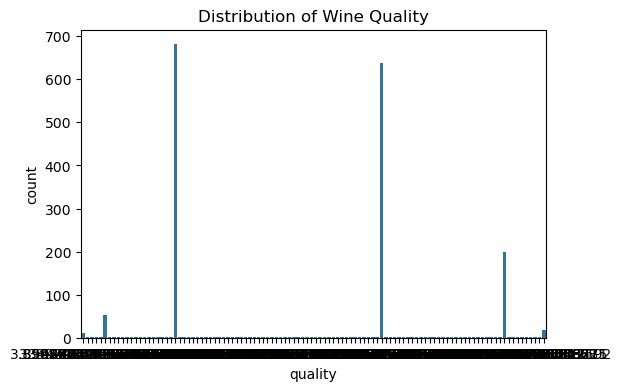

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='quality', data=df)
plt.title("Distribution of Wine Quality")
plt.show()


In [ ]:
# Most wines are quality 5 and 6
# Very few wines have high quality (7 or 8)

# Alcohol vs Quality

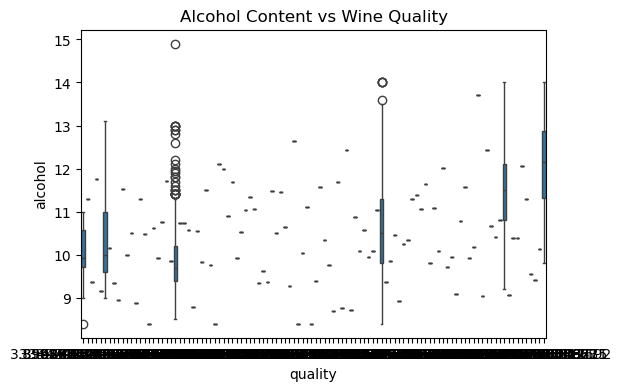

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title("Alcohol Content vs Wine Quality")
plt.show()


In [ ]:
# Insight:

#Higher quality wines usually have higher alcohol content.
#Alcohol seems positively related to quality.

# Volatile Acidity vs Quality

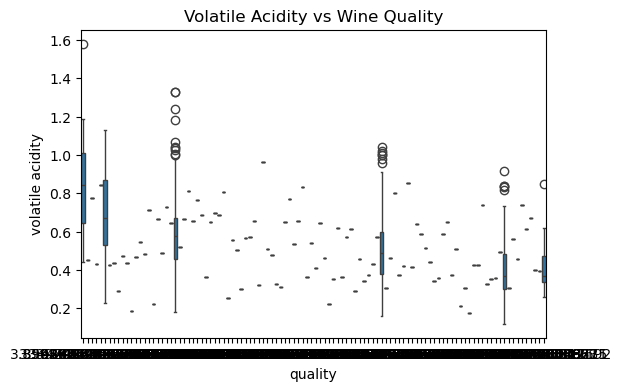

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x='quality', y='volatile acidity', data=df)
plt.title("Volatile Acidity vs Wine Quality")
plt.show()


In [ ]:
#Insight:

#Higher volatile acidity → Lower quality
#Strong negative relationship

# Correlation Heatmap

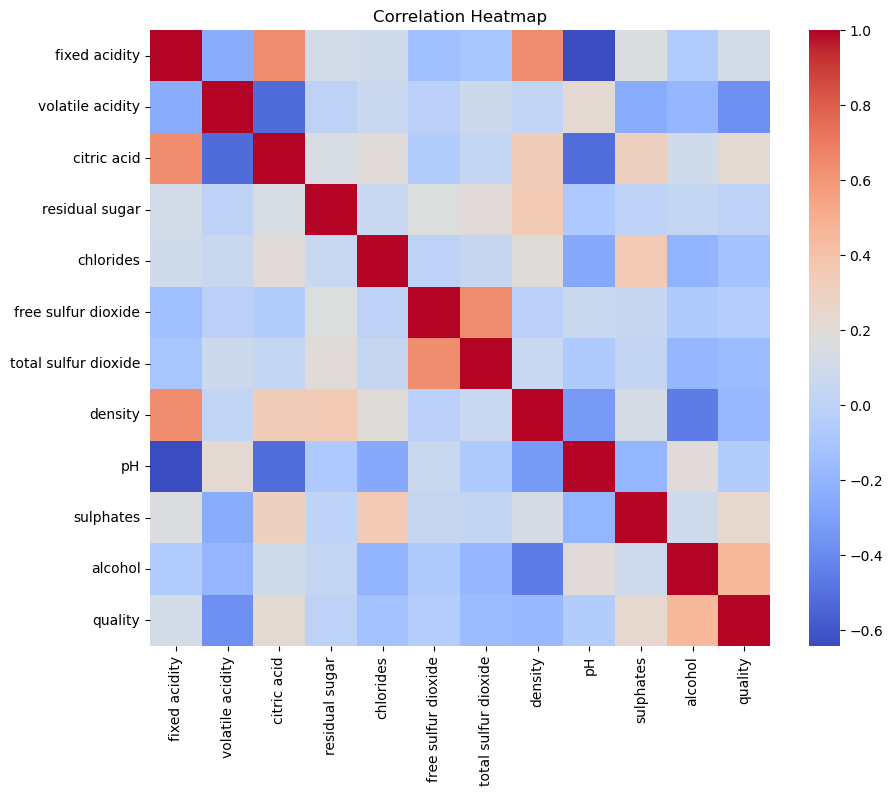

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
#Observe:

#Alcohol → Positive correlation with quality
#Volatile acidity → Negative correlation
#Sulphates → Slight positive impact

# Scatter Plot (Alcohol vs Quality)

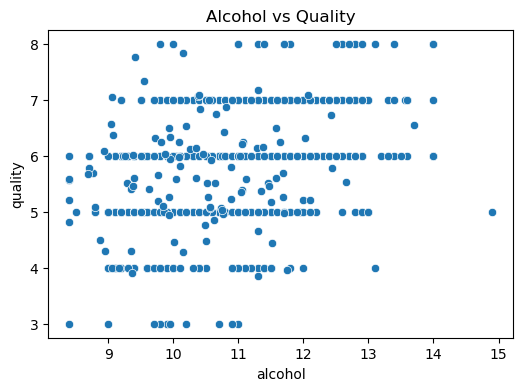

In [15]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='alcohol', y='quality', data=df)
plt.title("Alcohol vs Quality")
plt.show()


# Wine Quality – Simple Regression Mode

In [16]:
# Import Required Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [17]:
# Define Features (X) and Target (y)
# X = independent variables
X = df.drop("quality", axis=1)

# y = target variable
y = df["quality"]


In [19]:
# Split Dataset
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)


LinearRegression()

In [21]:
# Predict quality
y_pred = model.predict(X_test)


In [22]:
# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R2 Score
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 0.5274838305475673
RMSE: 0.6630775530354484
R2 Score: 0.273990246220589


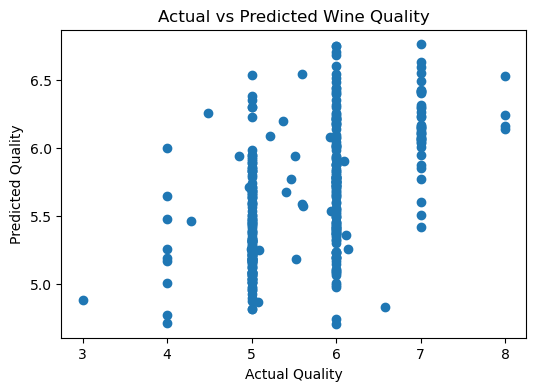

In [23]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted Wine Quality")
plt.show()


In [ ]:
#"I built a Linear Regression model to predict wine quality based on chemical properties. The model achieved an R² score of X, indicating moderate predictive power. Alcohol and sulphates showed positive contribution toward quality."